In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score, roc_auc_score
)

In [7]:
data = pd.read_csv("train_dataset_final1.csv")
data.head()
data.info()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25247 entries, 0 to 25246
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         25247 non-null  int64  
 1   marriage            25247 non-null  int64  
 2   sex                 25247 non-null  int64  
 3   education           25247 non-null  int64  
 4   LIMIT_BAL           25247 non-null  int64  
 5   age                 25121 non-null  float64
 6   pay_0               25247 non-null  int64  
 7   pay_2               25247 non-null  int64  
 8   pay_3               25247 non-null  int64  
 9   pay_4               25247 non-null  int64  
 10  pay_5               25247 non-null  int64  
 11  pay_6               25247 non-null  int64  
 12  Bill_amt1           25247 non-null  float64
 13  Bill_amt2           25247 non-null  float64
 14  Bill_amt3           25247 non-null  float64
 15  Bill_amt4           25247 non-null  float64
 16  Bill

Customer_ID             0
marriage                0
sex                     0
education               0
LIMIT_BAL               0
age                   126
pay_0                   0
pay_2                   0
pay_3                   0
pay_4                   0
pay_5                   0
pay_6                   0
Bill_amt1               0
Bill_amt2               0
Bill_amt3               0
Bill_amt4               0
Bill_amt5               0
Bill_amt6               0
pay_amt1                0
pay_amt2                0
pay_amt3                0
pay_amt4                0
pay_amt5                0
pay_amt6                0
AVG_Bill_amt            0
PAY_TO_BILL_ratio       0
next_month_default      0
dtype: int64

In [8]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer_ID,25247.0,17640.000000,7288.325459,5017.00,11328.500,17640.00,23951.500,30263.00
marriage,25247.0,1.551907,0.522629,0.00,1.000,2.00,2.000,3.00
sex,25247.0,0.604111,0.489050,0.00,0.000,1.00,1.000,1.00
education,25247.0,1.852101,0.797379,0.00,1.000,2.00,2.000,6.00
LIMIT_BAL,25247.0,168342.060443,129892.784807,10000.00,50000.000,140000.00,240000.000,1000000.00
age,25121.0,35.438199,9.174998,21.00,28.000,34.00,41.000,79.00
pay_0,25247.0,-0.042857,1.099315,-2.00,-1.000,0.00,0.000,8.00
pay_2,25247.0,-0.159544,1.173990,-2.00,-1.000,0.00,0.000,8.00
pay_3,25247.0,-0.190359,1.172636,-2.00,-1.000,0.00,0.000,8.00
pay_4,25247.0,-0.241415,1.146753,-2.00,-1.000,0.00,0.000,7.00


In [9]:

data.drop('Customer_ID', axis=1, inplace=True)
data.head()


,marriage,sex,education,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,pay_5,...,Bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,AVG_Bill_amt,PAY_TO_BILL_ratio,next_month_default
0,2,0,2,60000,25.0,2,2,2,0,0,...,20750.63,2000.21,0.00,1134.85,1821.78,1500.03,1500.24,41511.50,0.03,0
1,2,1,1,290000,24.0,0,0,-2,-2,-1,...,1350.30,0.00,0.17,0.00,2700.10,0.00,1349.72,2534.50,0.27,0
2,1,0,2,180000,63.0,0,0,0,0,0,...,52991.51,2086.94,2199.99,1845.66,2000.35,1923.00,1999.78,50422.00,0.04,0
3,1,1,2,210000,43.0,0,0,0,0,0,...,76945.47,3348.07,3380.91,3400.45,2683.97,2744.00,2892.10,86229.50,0.04,0
4,2,0,1,280000,32.0,-2,-2,-2,-2,-2,...,1.35,999.78,3186.27,45027.78,2100.09,0.01,0.27,11814.33,0.72,0


In [10]:
dp = data.duplicated().sum()
print(dp)
data = data.drop_duplicates()
dp = data.duplicated().sum()
print(dp)

803
0


In [11]:
print(data['age'].isnull().sum()) 
data = data.dropna(subset=['age']) #dropping missing values of ages because missing count is too small infront of train data
print(data['age'].isnull().sum()) 

126
0


next_month_default
0    19534
1     4784
Name: count, dtype: int64


([<matplotlib.patches.Wedge at 0x1bb612f4800>,
 [Text(-0.896520421949817, 0.6373783280179225, 'Non-Default'),
  Text(0.8965204816254785, -0.6373782440796204, 'Defaulter')])

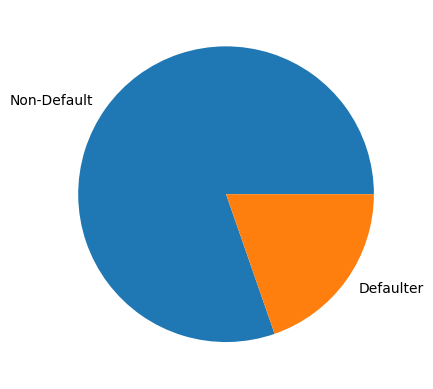

In [12]:
size = data['next_month_default'].value_counts()
print(size)
label = ["Non-Default","Defaulter" ]
plt.pie(size,labels=label)

# the data is quite imbalance.

In [13]:
print(data['sex'].value_counts())

sex
1    14700
0     9618
Name: count, dtype: int64


Text(0.5, 1.0, 'Default Status by Gender')

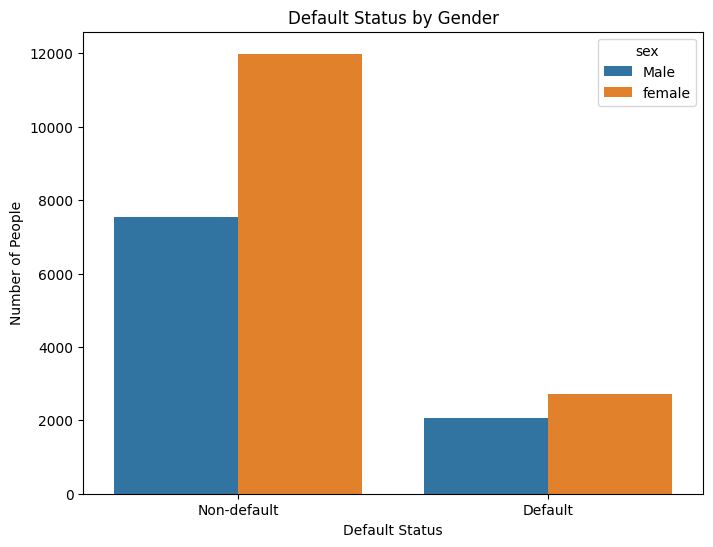

In [14]:
summary = data.groupby(['next_month_default', 'sex']).size().reset_index(name='count')
summary['next_month_default'] = summary['next_month_default'].map({0: 'Non-default', 1: 'Default'})
summary['sex'] = summary['sex'].map({0:'Male' , 1:'female'})
plt.figure(figsize=(8, 6))
sns.barplot(data=summary, x='next_month_default', y='count', hue='sex',)
plt.xlabel('Default Status')
plt.ylabel('Number of People')
plt.title('Default Status by Gender')



Text(0.5, 1.0, 'Limit Balance According to Age Groups')

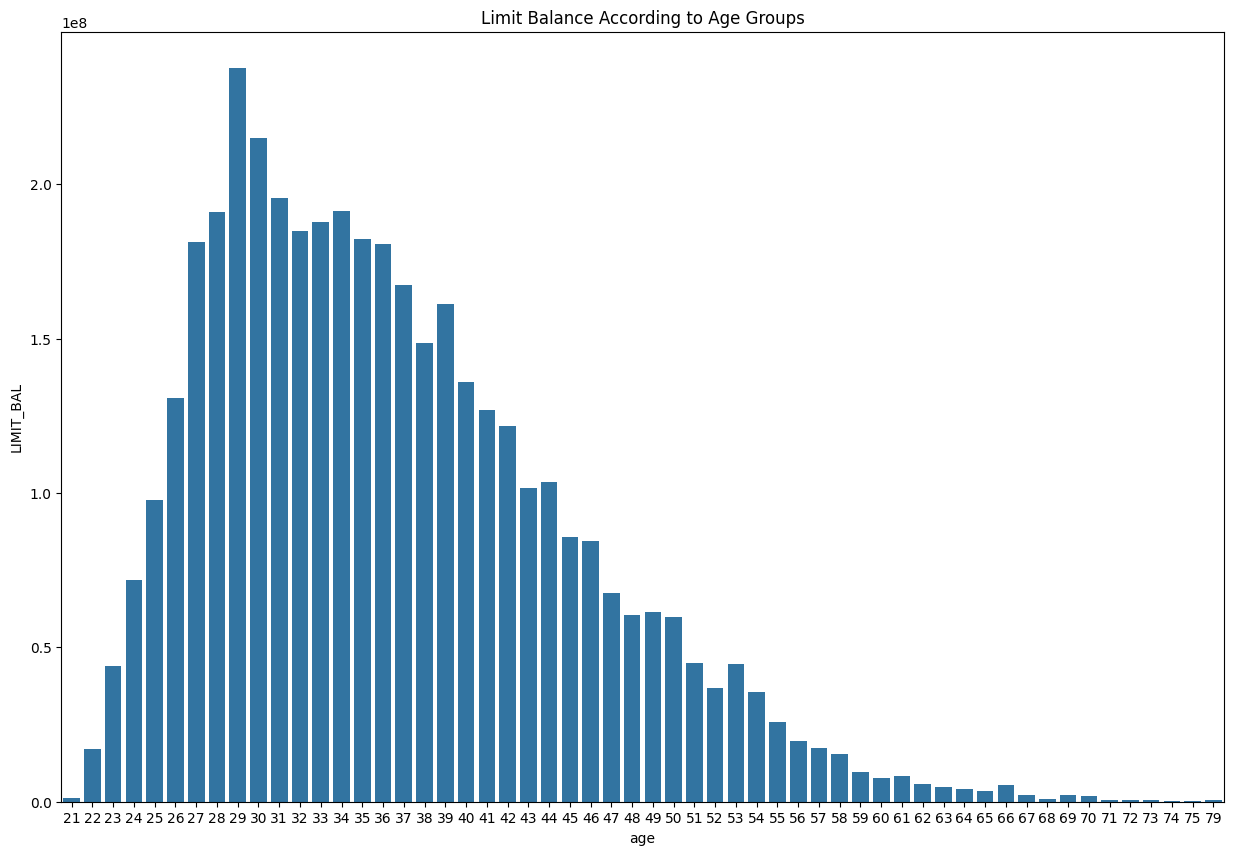

In [15]:
age_summary = data.groupby('age')['LIMIT_BAL'].sum().reset_index()
age_summary['age'] = age_summary['age'].astype(int)

plt.figure(figsize=(15, 10))
sns.barplot(data=age_summary, x='age', y='LIMIT_BAL')
# plt.xticks(rotation = 90)
plt.title('Limit Balance According to Age Groups')



In [16]:
counts_before = data['education'].value_counts()
print(counts_before)
data['education'] = data['education'].apply(lambda x:x if x<= 4 else 4).astype(int)
counts = data['education'].value_counts()
print(counts)

education
2    11284
1     8659
3     3963
5      246
4      111
6       41
0       14
Name: count, dtype: int64
education
2    11284
1     8659
3     3963
4      398
0       14
Name: count, dtype: int64


In [17]:
counts_before = data['marriage'].value_counts()
print(counts_before)
data['marriage'] = data['marriage'].apply(lambda x:x if x >0  else 3).astype(int)
counts = data['marriage'].value_counts()
print(counts)

marriage
2    12924
1    11081
3      263
0       50
Name: count, dtype: int64
marriage
2    12924
1    11081
3      313
Name: count, dtype: int64


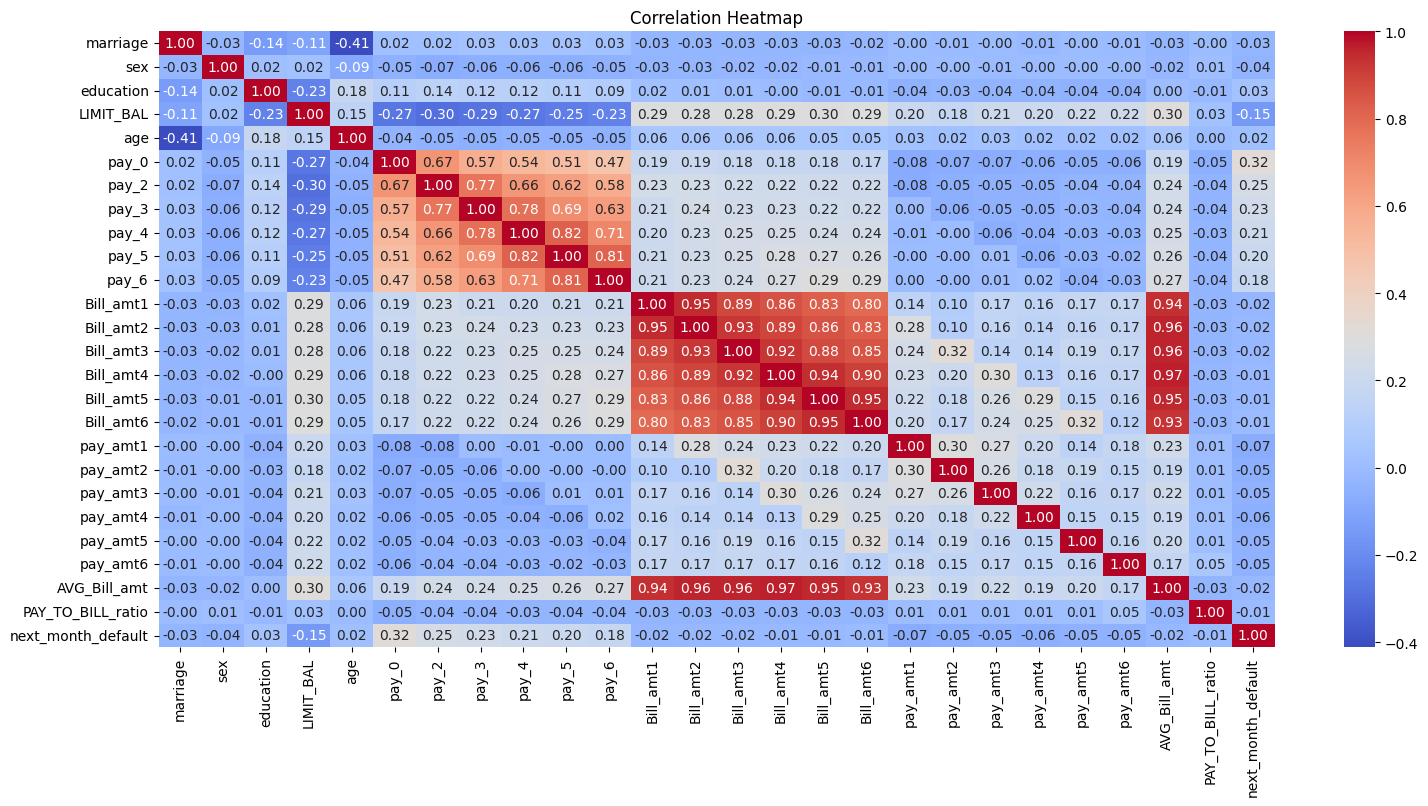

In [18]:
correlation_mat = data.corr()
plt.figure(figsize=(18,8))  
sns.heatmap(correlation_mat,fmt='.2f',annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [19]:
data.drop('AVG_Bill_amt', axis=1, inplace=True)


In [20]:
# one-hot encoding
data = pd.concat([data.drop(columns=['sex']), pd.get_dummies(data['sex'], prefix='sex')], axis=1)
data = pd.concat([data.drop(columns=['marriage']), pd.get_dummies(data['marriage'], prefix='marriage')], axis=1)
data = pd.concat([data.drop(columns=['education']), pd.get_dummies(data['education'], prefix='education')], axis=1)

In [21]:
data.head()

,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,Bill_amt1,Bill_amt2,...,sex_0,sex_1,marriage_1,marriage_2,marriage_3,education_0,education_1,education_2,education_3,education_4
0,60000,25.0,2,2,2,0,0,0,60323.86,60728.22,...,True,False,False,True,False,False,False,True,False,False
1,290000,24.0,0,0,-2,-2,-1,0,11157.67,0.00,...,False,True,False,True,False,False,True,False,False,False
2,180000,63.0,0,0,0,0,0,0,47930.96,48921.91,...,True,False,True,False,False,False,False,True,False,False
3,210000,43.0,0,0,0,0,0,0,91152.44,92916.01,...,False,True,True,False,False,False,False,True,False,False
4,280000,32.0,-2,-2,-2,-2,-2,-2,19666.40,999.04,...,True,False,False,True,False,False,True,False,False,False


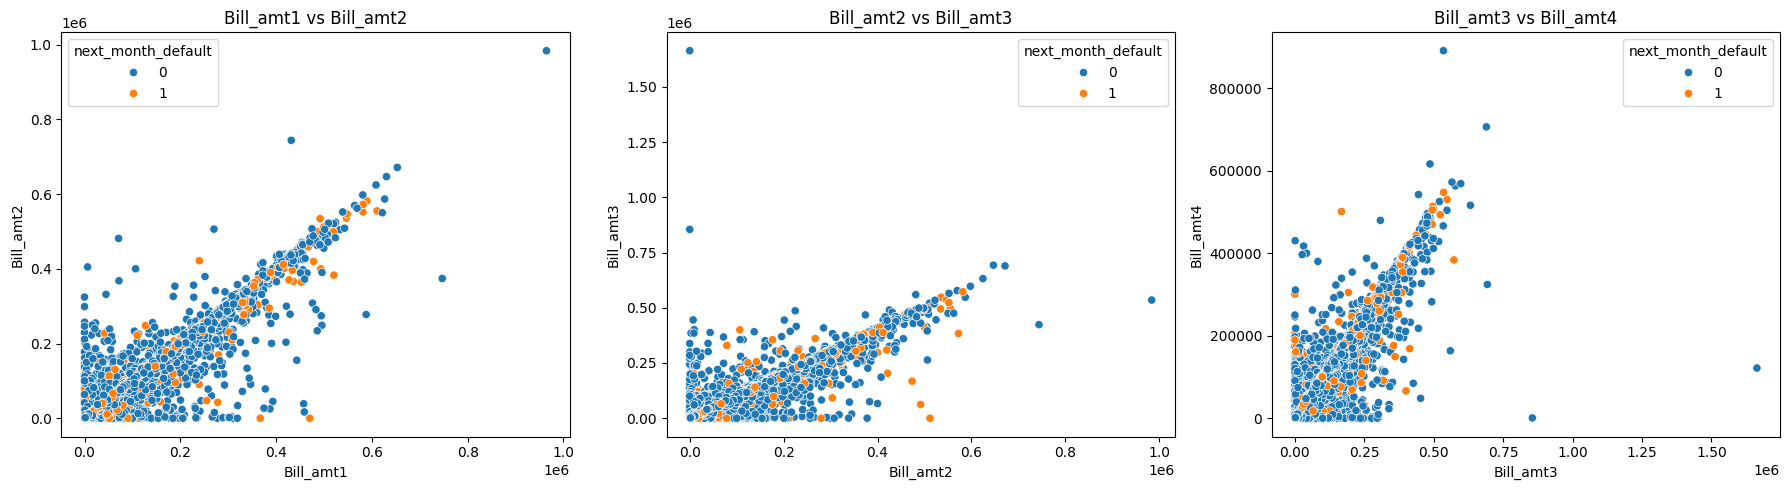

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


sns.scatterplot(x=data['Bill_amt1'], y=data['Bill_amt2'],hue=data['next_month_default'], ax=axes[0])
axes[0].set_title('Bill_amt1 vs Bill_amt2')


sns.scatterplot(x=data['Bill_amt2'], y=data['Bill_amt3'],hue=data['next_month_default'], ax=axes[1])
axes[1].set_title('Bill_amt2 vs Bill_amt3')


sns.scatterplot(x=data['Bill_amt3'], y=data['Bill_amt4'],hue=data['next_month_default'], ax=axes[2])
axes[2].set_title('Bill_amt3 vs Bill_amt4')

plt.tight_layout()
plt.show()

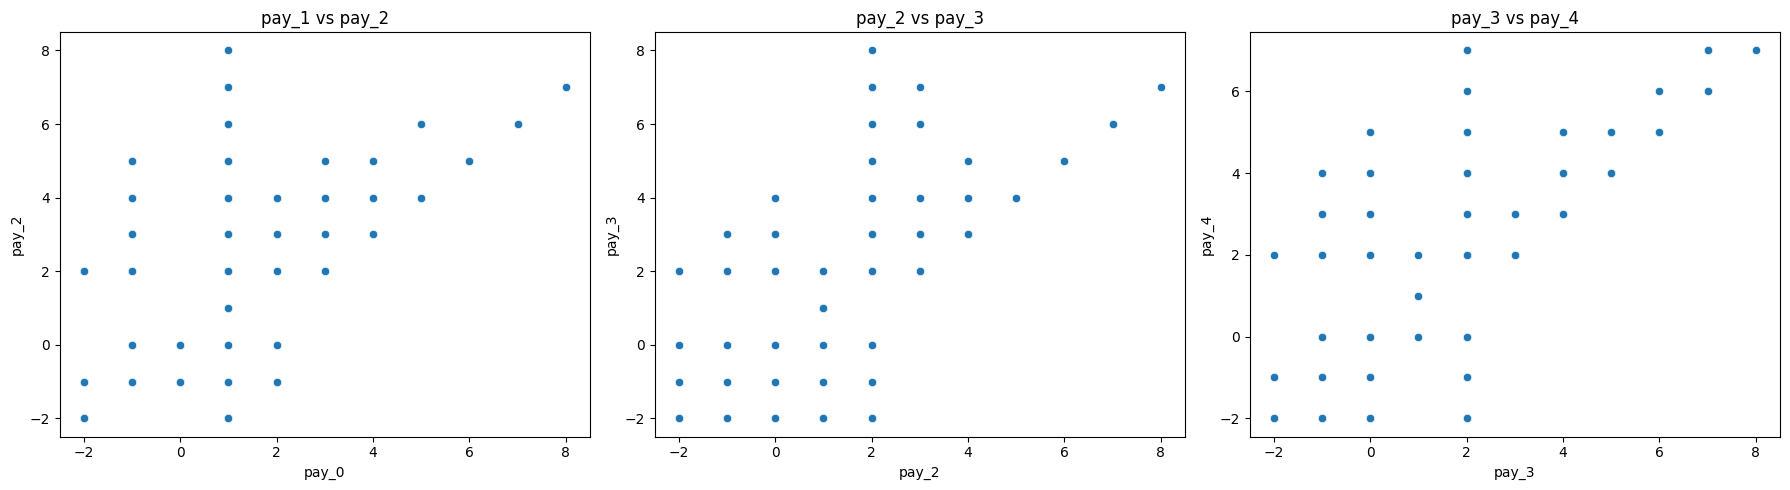

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=data['pay_0'], y=data['pay_2'], ax=axes[0])
axes[0].set_title('pay_1 vs pay_2')


sns.scatterplot(x=data['pay_2'], y=data['pay_3'], ax=axes[1])
axes[1].set_title('pay_2 vs pay_3')


sns.scatterplot(x=data['pay_3'], y=data['pay_4'], ax=axes[2])
axes[2].set_title('pay_3 vs pay_4')

plt.tight_layout()
plt.show()

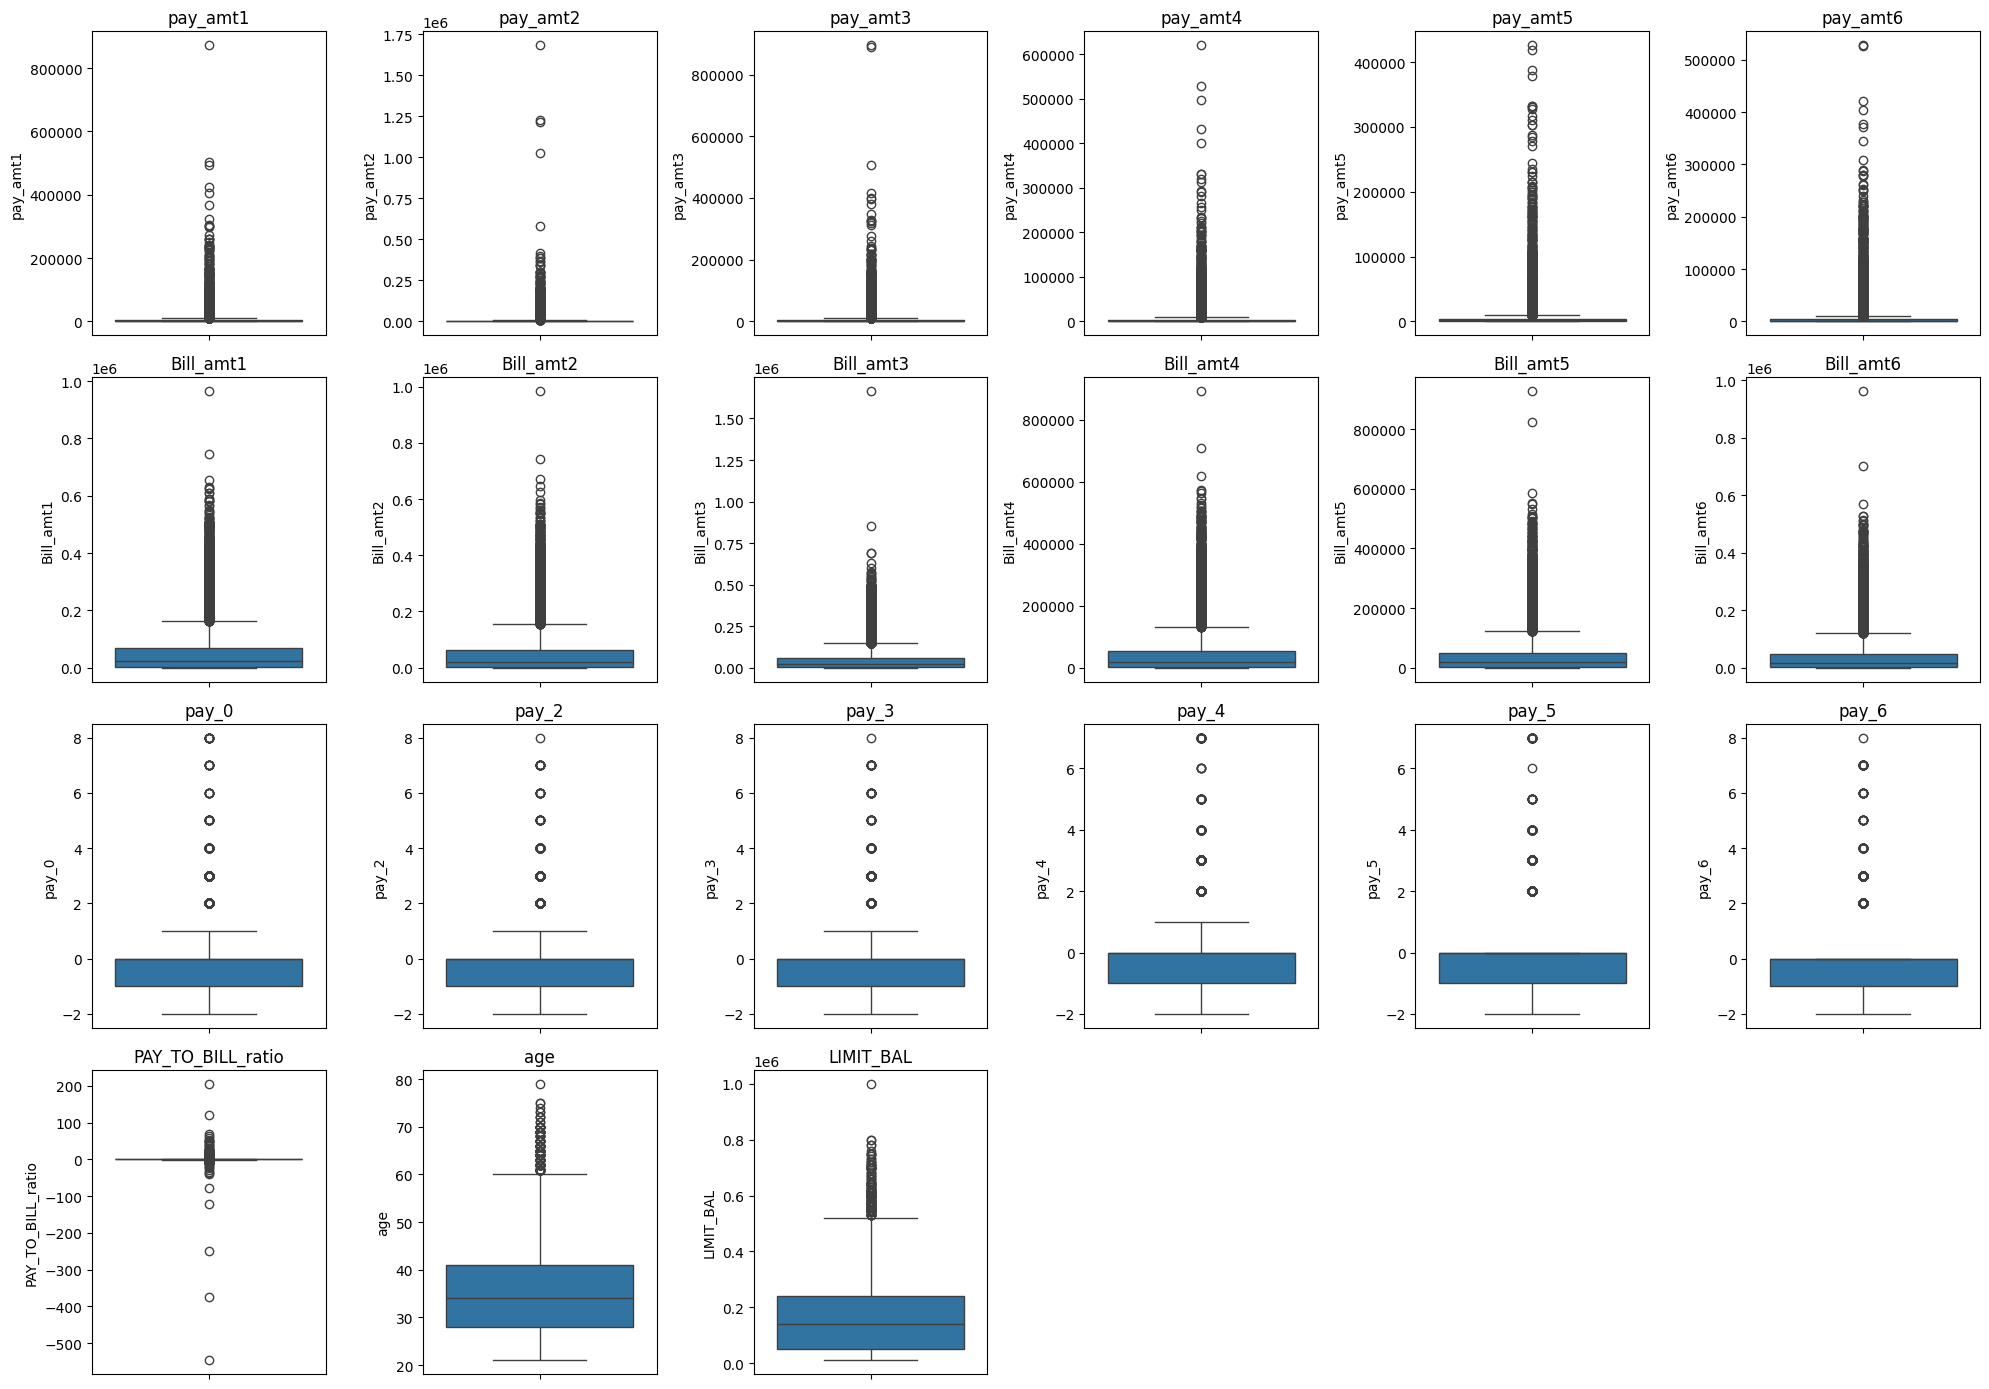

In [24]:
pay_amt_cols  = ['pay_amt1',  'pay_amt2',  'pay_amt3',  'pay_amt4',  'pay_amt5',  'pay_amt6']
bill_amt_cols = ['Bill_amt1', 'Bill_amt2', 'Bill_amt3', 'Bill_amt4', 'Bill_amt5', 'Bill_amt6']
pay_col = ['pay_0','pay_2','pay_3','pay_4','pay_5','pay_6']
other_col = ['PAY_TO_BILL_ratio','age','LIMIT_BAL']
all_col = pay_amt_cols + bill_amt_cols + pay_col + other_col

n_cols = 6
n_rows = (len(all_col) + n_cols - 1) // n_cols  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3.5 * n_rows))
axes = axes.flatten() 

for i, col in enumerate(all_col):
    sns.boxplot(y=data[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")  

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [25]:
target_col = 'next_month_default'  

X = data.drop(columns=[target_col])
y = data[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(y_train.value_counts())
print(y_test.value_counts())


next_month_default
0    14650
1     3588
Name: count, dtype: int64
next_month_default
0    4884
1    1196
Name: count, dtype: int64


In [26]:
scaler = StandardScaler() 
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

Explained Variance Ratio (per component):
Component 1: 0.2124
Component 2: 0.1350
Component 3: 0.0783
Component 4: 0.0654
Component 5: 0.0517
Component 6: 0.0443
Component 7: 0.0394
Component 8: 0.0331
Component 9: 0.0324
Component 10: 0.0323
Component 11: 0.0319
Component 12: 0.0299
Component 13: 0.0292
Component 14: 0.0279
Component 15: 0.0267
Component 16: 0.0260
Component 17: 0.0219
Component 18: 0.0203
Component 19: 0.0169
Component 20: 0.0131
Component 21: 0.0085
Component 22: 0.0079
Component 23: 0.0062
Component 24: 0.0043
Component 25: 0.0021
Component 26: 0.0014
Component 27: 0.0008
Component 28: 0.0007
Component 29: 0.0000
Component 30: 0.0000
Component 31: 0.0000
[0.21239764 0.34744095 0.42569556 0.49113265 0.54281401 0.58708335
 0.62644986 0.65959274 0.69200198 0.72434243 0.7561999  0.78607515
 0.81528192 0.84319589 0.86992995 0.89591256 0.91783914 0.93810778
 0.95500947 0.96810448 0.97663472 0.98453616 0.99075558 0.99506497
 0.99712705 0.99848998 0.99928902 1.         1. 

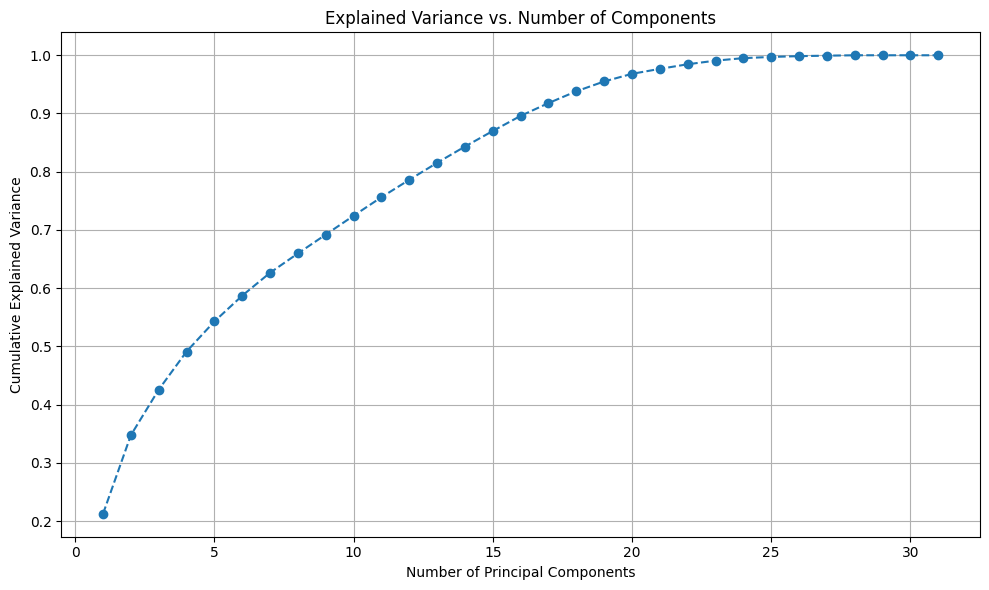

In [27]:
pca = PCA()
X_train_pca = pca.fit_transform(X_train)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

print("Explained Variance Ratio (per component):")
for i, var in enumerate(explained_variance):
    print(f"Component {i+1}: {var:.4f}")

print(cumulative_variance)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
no_pc = 22
pca = PCA(n_components=no_pc)
pca.fit(X_train)

X_pca_train_val = pd.DataFrame(pca.transform(X_train))
X_pca_test = pd.DataFrame(pca.transform(X_test))
X_pca_train_val.columns = ['PC' + str(i) for i in range(1, no_pc+1) ]
X_pca_test.columns = ['PC' + str(i) for i in range(1, no_pc+1) ]
X_pca_train_val.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22
0,-3.044627,-1.426846,-2.496609,-1.061697,1.300793,-0.681534,-0.099684,-0.214814,-0.119871,-0.044586,...,-0.000128,-0.052365,0.154176,0.004669,0.095333,0.882405,-1.668327,-0.106897,-0.212105,-0.149718
1,2.100922,-1.110158,-1.362550,-1.348830,0.782991,2.298266,0.207800,-0.373027,-0.600488,-0.382435,...,-1.631149,-2.879077,1.854136,3.603081,-0.860191,-1.140203,-0.357218,0.401616,-0.077286,-0.386373
2,-1.284537,1.124678,1.331747,-1.550075,1.190011,0.271055,0.362562,0.003846,-0.056922,0.018200,...,-0.073790,0.315654,0.275172,-0.059044,0.241061,-0.014891,0.239525,-0.190571,-0.121195,-0.019568
3,0.987095,0.579497,1.449997,-1.690159,1.340102,-0.481875,0.305014,-0.058724,-0.015172,0.059514,...,0.065115,0.192362,0.004337,-0.136766,0.087674,-0.463147,0.002741,-0.062235,-0.003146,0.280760
4,5.582867,-2.104604,-1.350477,-1.653906,1.258078,-1.148727,-0.611460,-0.287863,0.049200,0.087082,...,-0.194388,0.080445,-0.015444,0.006073,-0.049361,-0.610073,-0.009547,0.110778,0.112273,-0.933004


In [29]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_sampled , y_train_sampled = smote.fit_resample(X_pca_train_val, y_train)


In [30]:
models = {
    "DecisionTree": DecisionTreeClassifier(max_depth=10, min_samples_split=2, criterion='gini', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, reg_lambda=1, use_label_encoder=False, eval_metric='logloss', random_state=42,max_depth = 3),
    "LightGBM": LGBMClassifier(n_estimators=100, boosting_type='dart', random_state=42,objective = 'binary',max_depth= -1 ),
    "Logistic": LogisticRegression(C=0.01, solver='liblinear', penalty='l2', random_state=42 , max_iter=10000),
    "AdaBoost" : AdaBoostClassifier(n_estimators=200,learning_rate=0.1,random_state=42),
    "Support Vector Machine" : SVC(C=0.1 , gamma='scale',kernel='rbf',probability=True,random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_sampled, y_train_sampled)
    y_proba = model.predict_proba(X_pca_test)[:, 1]
    
    best_f2 = 0
    best_metrics = {}
    best_thresh = 0
    
    for thresh in np.arange(0.1, 0.51, 0.01):
        y_pred = (y_proba >= thresh).astype(int)
        
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        f2 = fbeta_score(y_test, y_pred, beta=2)
        auc = roc_auc_score(y_test, y_proba)
        
        if f2 > best_f2:
            best_f2 = f2
            best_thresh = thresh
            best_metrics = {
                "Model": name,
                "Best_Threshold": round(thresh, 2),
                "Accuracy": round(acc, 4),
                "Precision": round(prec, 4),
                "Recall": round(rec, 4),
                "F1": round(f1, 4),
                "F2": round(f2, 4),
                "ROC_AUC": round(auc, 4)
            }
    
    results.append(best_metrics)
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

C:\Users\manth\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [11:26:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 14650, number of negative: 14650
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003610 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5610
[LightGBM] [Info] Number of data points in the train set: 29300, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


C:\Users\manth\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


                 Model  Best_Threshold  Accuracy  Precision  Recall     F1     F2  ROC_AUC
          DecisionTree            0.19    0.4648     0.2440  0.8202 0.3762 0.5571   0.6993
               XGBoost            0.34    0.5390     0.2780  0.8411 0.4179 0.5986   0.7594
              LightGBM            0.31    0.4921     0.2612  0.8654 0.4013 0.5917   0.7607
              Logistic            0.35    0.4339     0.2388  0.8587 0.3737 0.5653   0.7234
              AdaBoost            0.49    0.3901     0.2350  0.9314 0.3753 0.5848   0.7526
Support Vector Machine            0.30    0.4980     0.2649  0.8746 0.4067 0.5989   0.7554
